# Fiber estimation from activation maps

This tutorial estimates surface fiber orientation and conduction speeds from
several local activation-time maps. We first generate synthetic measurements
with a known fiber field, then infer a shared conduction tensor using an
anisotropic eikonal model, following the FiberNet approach ([Herrera (2022)](https://doi.org/10.1007/s00366-022-01709-3), [Magaña (2025)](https://doi.org/10.1113/JP288001))

## 1. Prepare the dataset

Let $S$ denote the cardiac surface and $T_m(x)$ the activation time for stimulation
$m$. Different stimulation sites probe the same tissue from different propagation
directions, providing complementary information about anisotropy.

Identify the apex and basal boundary on the ventricular surface; these landmarks anchor the longitudinal coordinate.


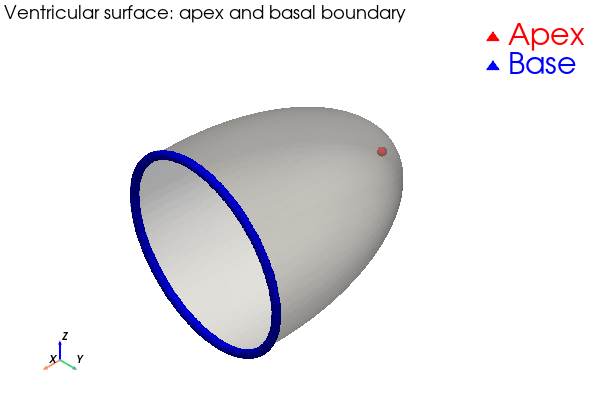

In [7]:
from pathlib import Path
from finitewave_tools.visualization import PyVistaSurfaceGrid
import numpy as np
import pyvista as pv

path = Path("./data")

points = np.load(path / "lv_surface_points.npy")
elems = np.load(path / "lv_surface_elements.npy")

apex_point_id = np.argmin(points[:, 0])

poly = PyVistaSurfaceGrid(points, elems)
poly["point_ids"] = np.arange(points.shape[0])
base_point_id = poly.extract_feature_edges()["point_ids"]

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(600, 400))
pl.add_mesh(poly, color="lightgrey", opacity=0.5)
pl.add_points(points[apex_point_id], color="red", point_size=10,
              render_points_as_spheres=True, label="Apex")
pl.add_points(points[base_point_id], color="blue", point_size=10,
              render_points_as_spheres=True, label="Base")
pl.add_text('Ventricular surface: apex and basal boundary', position="upper_left", font_size=12)
pl.add_axes(xlabel="X", ylabel="Y", zlabel="Z")
pl.add_legend(loc="upper right", size=(0.2, 0.16))
pl.show()

### 1.1. Build the coordinate system

A harmonic coordinate runs from the apex to the base:

$$
\Delta_S u=0,\qquad u|_{\mathrm{apex}}=-1,\qquad u|_{\mathrm{base}}=1.
$$

Its normalized surface gradient defines a longitudinal reference direction.
Together with the surface normal $n$, it gives a local tangent basis:

$$
l=\frac{\nabla_S u}{\|\nabla_S u\|},\qquad c=l\times n.
$$

This reference frame defines how fiber angles are measured; it is not the
unknown fiber orientation itself.

Solve for the harmonic coordinate and visualize its tangent directions to check the local reference frame.


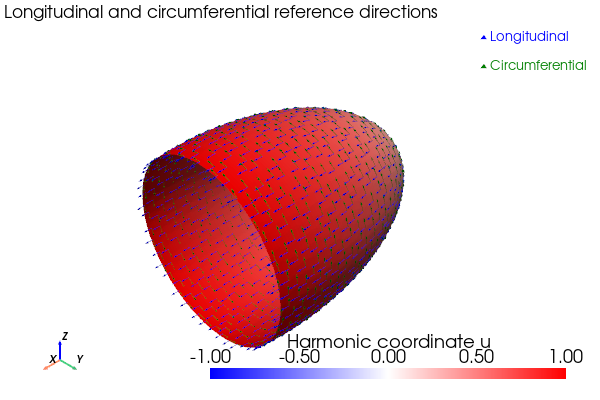

In [8]:
import finitewave as fw
import finitewave_tools.linalg as fwl
import finitewave_tools.meshkit as fwm


def build_system_matrices(points, elems):
    discretization = fw.FiniteElementDiscretization()
    discretization.reference_element = fw.LinearTriangleElement()
    K, M = discretization.build_system_matrices(points, elems)
    G = discretization.build_gradient_operator(points, elems)
    return K, M, G


def solve_laplace(K, boundary_conditions):
    A, b, x0, internal_inds = fwl.make_system(K, dirichlet_conditions=boundary_conditions)
    x0[internal_inds] = fwl.linear_solver(A, b, x0[internal_inds])
    return x0


def compute_grads(G, x):
    grads = np.array([g @ x for g in G])
    grads_norm = np.linalg.norm(grads, axis=0, keepdims=True)
    grads_normalized = grads / grads_norm
    return grads_normalized


def build_coord_system(G, x, normals):
    long_vec = compute_grads(G, x).T
    circ_vec = np.cross(long_vec, normals)
    circ_vec = circ_vec / np.linalg.norm(circ_vec, axis=1, keepdims=True)
    return long_vec, circ_vec, normals


K, M, G = build_system_matrices(points, elems)
x0 = solve_laplace(K, ((apex_point_id, -1.0), (base_point_id, 1.0)))

long_vec, circ_vec, normal_vec = build_coord_system(G, x0, poly.cell_normals)
elem_centers = np.mean(points[elems], axis=1)
random_point_ids = fwm.select_random_points(elem_centers, distance=2, seed=42)

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(600, 400))
pl.add_mesh(poly, color="lightgray", opacity=1., show_edges=False)
pl.add_arrows(elem_centers[random_point_ids], long_vec[random_point_ids],
              mag=2.0, color="blue", opacity=1.0, label="Longitudinal")
pl.add_arrows(elem_centers[random_point_ids], circ_vec[random_point_ids],
              mag=2.0, color="green", opacity=1.0, label="Circumferential")
pl.add_mesh(poly, scalars=x0, cmap="bwr", opacity=1., show_edges=False,
            scalar_bar_args={"title": "Harmonic coordinate u", "fmt": "%.2f"})
pl.add_text('Longitudinal and circumferential reference directions', position="upper_left", font_size=12)
pl.add_axes(xlabel="X", ylabel="Y", zlabel="Z")
pl.add_legend(loc="upper right", size=(0.2, 0.16))
pl.show()

### 1.2. Generate fibers

Prescribe an angle relative to the longitudinal direction and rotate within the
tangent plane:

$$
f=\cos\alpha\,l+\sin\alpha\,c,\qquad
\alpha(x)=\frac{\pi}{2}\frac{1}{1+\exp[-(x_1-\mu)/\sigma]}.
$$

Here $x_1$ is the first spatial coordinate; $\mu$ and $\sigma$ control the location
and width of the transition. Reaction–diffusion simulations with several
stimulation sites generate the reference activation maps.

Plot the prescribed angle $\alpha$ to inspect the transition from longitudinal to circumferential alignment.


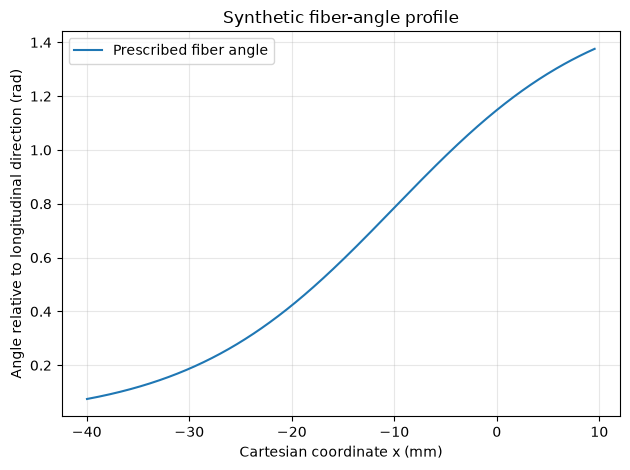

In [9]:
import matplotlib.pyplot as plt
import numpy as np


def sigmoid_func(x, mu=-10.0, sigma=10.0):
    return 1.0 / (1.0 + np.exp(-(x - mu) / sigma))


x = elem_centers[:, 0]  # Basis vectors are defined per triangle.
angles = np.pi/2 * sigmoid_func(x, mu=-10, sigma=10)
inds = np.argsort(x)

plt.figure()
plt.plot(x[inds], angles[inds], label="Prescribed fiber angle")
plt.title("Synthetic fiber-angle profile")
plt.xlabel("Cartesian coordinate x (mm)")
plt.ylabel("Angle relative to longitudinal direction (rad)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Rotate the reference directions by $\alpha$ and display the resulting synthetic fiber field.


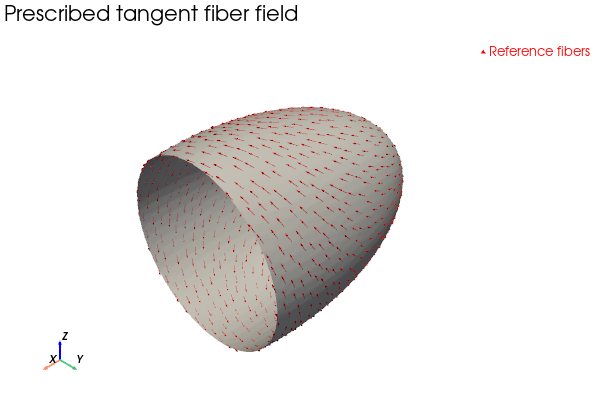

In [10]:
import numpy as np


def sigmoid_func(x, mu=-10.0, sigma=10.0):
    return 1.0 / (1.0 + np.exp(-(x - mu) / sigma))

x = elem_centers[:, 0]  # Basis vectors are defined per triangle.
angles = np.pi/2 * sigmoid_func(x, mu=-10, sigma=10)

fibers = np.cos(angles)[:, np.newaxis] * long_vec + np.sin(angles)[:, np.newaxis] * circ_vec
fibers = fibers / np.linalg.norm(fibers, axis=1, keepdims=True)

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(600, 400))
pl.add_mesh(poly, color="lightgray", opacity=1., show_edges=False)
pl.add_arrows(elem_centers[random_point_ids], fibers[random_point_ids],
              mag=2.0, color="red", opacity=1.0, label="Reference fibers")
pl.add_text('Prescribed tangent fiber field', position="upper_left", font_size=12)
pl.add_axes(xlabel="X", ylabel="Y", zlabel="Z")
pl.add_legend(loc="upper right", size=(0.2, 0.16))
pl.show()

### 1.3. Sample stimulation points

Select separated stimulation sites so that the activation maps probe propagation from different locations.


5 random stimulation points selected.


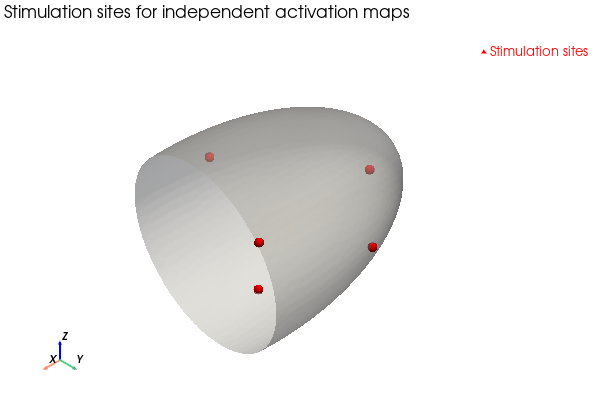

In [11]:
random_stim_ids = fwm.select_random_points(points, distance=28, seed=45)
print(len(random_stim_ids), "random stimulation points selected.")

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(600, 400))
pl.add_mesh(poly, color="lightgray", opacity=.5, show_edges=False)
pl.add_points(points[random_stim_ids], color="red", point_size=10,
              render_points_as_spheres=True, label="Stimulation sites")
pl.add_text('Stimulation sites for independent activation maps', position="upper_left", font_size=12)
pl.add_axes(xlabel="X", ylabel="Y", zlabel="Z")
pl.add_legend(loc="upper right", size=(0.2, 0.16))
pl.show()

Simulate excitation from each site and record the local activation time $T_m(x)$ at the chosen voltage threshold.


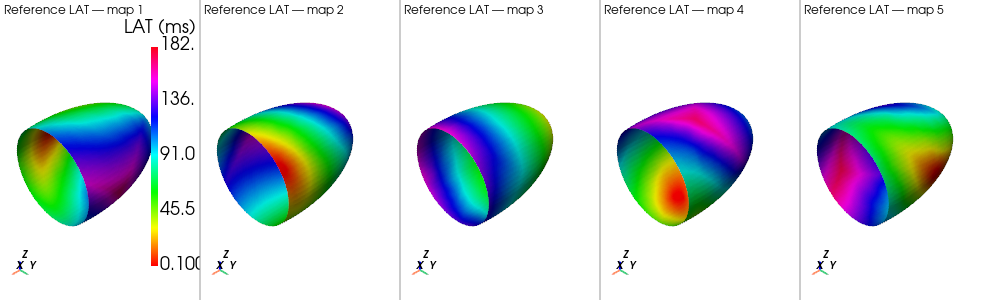

In [ ]:
import finitewave as fw
from finitewave_tools.meshkit.points.point_sampler import select_random_points


def run_simulation(points, elems, fibers, stim_point_id):
    cardiac_tissue = fw.CardiacTissue(coords=points, elems=elems,
                                      elem_type=fw.ElementType.TRIANGLE)
    cardiac_tissue.fibers = fibers
    cardiac_tissue.D_ac = 1 / 4

    lat_tracker = fw.ActivationTimeTracker(threshold=0.5, step=10)

    # create model object and set up parameters:
    simulation = fw.CardiacSimulation(dt=0.01, t_max=200, backend="jax")
    simulation.cardiac_tissue = cardiac_tissue
    simulation.cardiac_model = fw.BuenoOrovio()
    simulation.time_integration = fw.BackwardEulerTimeIntegration(atol=1e-8, maxiter=100, lumping_factor=1.0, reaction_lumping=True)
    simulation.stim_sequence = fw.StimSequence()
    simulation.stim_sequence.add_stim(
        fw.StimCurrentElectrodes(time=0, curr_value=20, duration=0.5, 
                                coords=[points[stim_point_id]],
                                size=2))
    simulation.tracker_sequence = fw.TrackerSequence()
    simulation.tracker_sequence.add_tracker(lat_tracker)

    # run the model:
    simulation.run()

    lats = lat_tracker.act_t
    return lats


lats = [run_simulation(points, elems, fibers, stim_point_id) for stim_point_id in random_stim_ids]
lats = np.array(lats)

pv.set_jupyter_backend("static")
pl = pv.Plotter(shape=(1, len(lats)), window_size=(1000, 300))

for i in range(len(lats)):
    pl.subplot(0, i)
    pl.add_text(f"Reference LAT — map {i + 1}", font_size=10)
    pl.add_axes()
    pl.add_mesh(poly, scalars=lats[i], cmap="hsv", opacity=1.,
                show_edges=False, 
                scalar_bar_args={"title": "LAT (ms)", "vertical": True, 
                                 "position_x": 0.75, "position_y": 0.1,
                                 "width": 0.1, "height": 0.8})
pl.link_views()
pl.show()

Optionally save the synthetic activation maps for reuse in the inverse problem.


In [ ]:
# path_output = Path("./output")
# np.save(path_output / "lats.npy", np.array(lats, dtype=np.float32))

## 2. Estimate fibers from activation maps

We fit the activation maps and a common conduction tensor jointly. The
activation measurements constrain the fit, while the eikonal equation supplies
a physical relation between activation gradients and conduction [(Raissi (2019))](https://doi.org/10.1016/j.jcp.2018.10.045).
The eikonal description is an approximation to the reaction–diffusion
simulations used to generate the data.

Load the surface and previously generated activation maps as the reference observations.


In [ ]:
# from pathlib import Path
# import numpy as np


# path_output = Path("./output")
# path = Path("./data")
# points = np.load(path / "lv_surface_points.npy")
# elems = np.load(path / "lv_surface_elements.npy")
# lats = np.load(path_output / "lats.npy")

Reduce the surface resolution and transfer activation times from the nearest original locations to lower the cost of fitting.


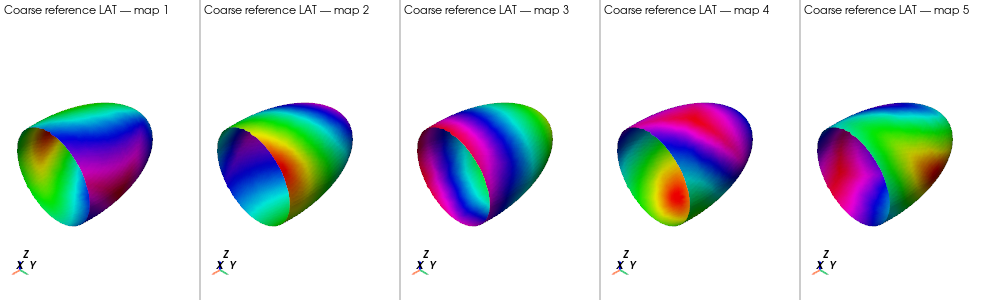

In [12]:
import pyacvd
import pyvista as pv
from scipy import spatial
from finitewave_tools.visualization import PyVistaSurfaceGrid


def downsample_mesh(poly, target_num_faces=2000):
    clus = pyacvd.Clustering(poly)
    clus.subdivide(3)
    clus.cluster(target_num_faces)

    poly_coarse = clus.create_mesh()

    points_coarse = poly_coarse.points
    elems_coarse = poly_coarse.faces.reshape(-1, 4)[:, 1:]

    return points_coarse, elems_coarse


def find_nearest_neighbors(source_points, target_points):
    tree = spatial.cKDTree(target_points)
    _, indices = tree.query(source_points)
    return indices


poly = PyVistaSurfaceGrid(points, elems)
points_coarse, elems_coarse = downsample_mesh(poly, target_num_faces=2000)

poly_coarse = PyVistaSurfaceGrid(points_coarse, elems_coarse)
nearest_neighbor_indices = find_nearest_neighbors(points_coarse, points)
lats_coarse = lats[:, nearest_neighbor_indices]

pv.set_jupyter_backend("static")
pl = pv.Plotter(shape=(1, len(lats_coarse)), window_size=(1000, 300))
for i in range(len(lats_coarse)):
    pl.subplot(0, i)
    pl.add_text(f"Coarse reference LAT — map {i + 1}", font_size=10)
    pl.add_axes()
    pl.add_mesh(poly_coarse, scalars=lats_coarse[i], cmap="hsv", opacity=1.,
                show_edges=False, show_scalar_bar=False)
pl.link_views()
pl.show()

### 2.1. Describe the surface with eigenfunctions

Surface eigenfunctions provide geometric inputs [(Costabal (2024))](https://arxiv.org/abs/2209.03984):

$$
-\Delta_S\psi_k=\lambda_k\psi_k,
\qquad K\psi_k=\lambda_k M\psi_k.
$$

Here $K$ and $M$ are the finite-element stiffness and mass matrices. The values
$\psi_k(x)$ describe location through the surface geometry. This tutorial uses
these spectral inputs in place of the Cartesian coordinates used in FiberNet.

Compute surface eigenfunctions and visualize selected modes, from broad spatial patterns to finer variation.


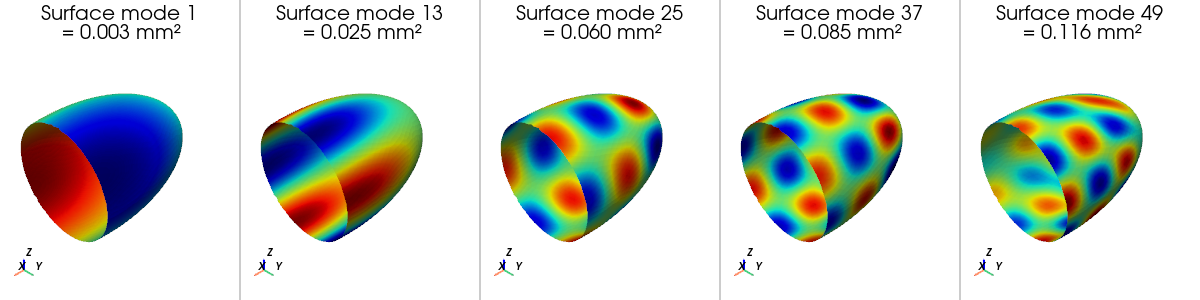

In [13]:
from scipy import sparse

N_EIGS = 50
K_coarse, M_coarse, G_coarse = build_system_matrices(points_coarse, elems_coarse)
eigvals, eigvecs = sparse.linalg.eigsh(K_coarse, k=N_EIGS, M=M_coarse, which='SM')

pl = pv.Plotter(shape=(1, 5), window_size=(1200, 300))

for i, idx in enumerate([1, 13, 25, 37, 49]):
    pl.subplot(0, i)
    pl.add_axes()
    pl.add_text(f"Surface mode {idx}\nλ = {eigvals[idx]:.3f} mm⁻²", position="upper_edge",
                font_size=8,)
    pl.add_mesh(poly_coarse, scalars=eigvecs[:, idx], show_edges=False,
                show_scalar_bar=False, cmap="jet")
pl.link_views()
pl.show()

Reconstruct the tangent reference frame and the prescribed fibers on the coarser surface for later comparison.


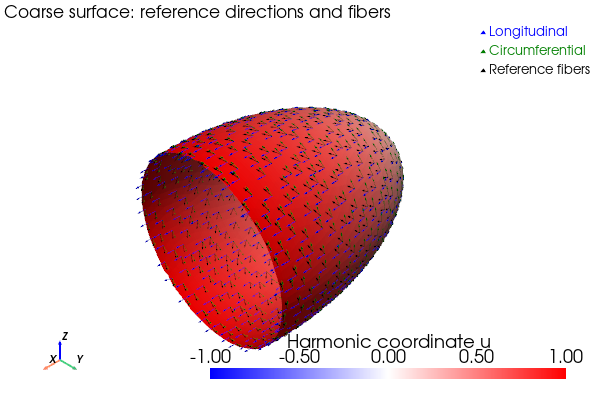

In [14]:
apex_point_id = np.argmin(points_coarse[:, 0])
poly_coarse["point_ids"] = np.arange(points_coarse.shape[0])
base_point_id = np.unique(poly_coarse.extract_feature_edges(non_manifold_edges=False, feature_edges=False, manifold_edges=False)["point_ids"])

x0 = solve_laplace(K_coarse, ((apex_point_id, -1.0), (base_point_id, 1.0)))

long_coarse, circ_coarse, normal_coarse = build_coord_system(G_coarse, x0, poly_coarse.cell_normals)
elem_centers = np.mean(points_coarse[elems_coarse], axis=1)
random_point_ids = fwm.select_random_points(elem_centers, distance=2, seed=42)

angles_coarse = np.pi/2 * sigmoid_func(elem_centers[:, 0], mu=-10, sigma=10)
fibers_coarse = (np.cos(angles_coarse)[:, np.newaxis] * long_coarse +
                 np.sin(angles_coarse)[:, np.newaxis] * circ_coarse)
fibers_coarse = fibers_coarse / np.linalg.norm(fibers_coarse, axis=1, keepdims=True)

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(600, 400))
pl.add_arrows(elem_centers[random_point_ids], long_coarse[random_point_ids],
              mag=2.0, color="blue", opacity=1.0, label="Longitudinal")
pl.add_arrows(elem_centers[random_point_ids], circ_coarse[random_point_ids],
              mag=2.0, color="green", opacity=1.0, label="Circumferential")
pl.add_arrows(elem_centers[random_point_ids], fibers_coarse[random_point_ids],
              mag=2.0, color="black", opacity=1.0, label="Reference fibers")
pl.add_mesh(poly_coarse, scalars=x0, cmap="bwr", opacity=1., show_edges=False,
            scalar_bar_args={"title": "Harmonic coordinate u", "fmt": "%.2f"})
pl.add_text('Coarse surface: reference directions and fibers', position="upper_left", font_size=12)
pl.add_axes(xlabel="X", ylabel="Y", zlabel="Z")
pl.add_legend(loc="upper right", size=(0.2, 0.16))
pl.show()

### 2.2. Enforce the anisotropic eikonal equation

Let $\widetilde T_m=T_m/s_m$ denote normalized local activation time, where $s_m>0$ is the time scale for map $m$. Define the residual

$$
r_m=s_m\sqrt{\nabla_S\widetilde T_m^T D\nabla_S\widetilde T_m}-1.
$$

Let $N_m$ be the number of observations in map $m$, and
$\omega_e=A_e/\sum_j A_j$ the normalized triangle area. The losses are

$$
\mathcal L_d=\frac1{N_{\mathrm{maps}}}\sum_m
\frac1{N_m}\sum_i[\widehat{\widetilde T}_m(x_{mi})-\widetilde T_{mi}]^2,
\qquad
\mathcal L_p=\frac1{N_{\mathrm{maps}}}\sum_m\sum_e\omega_e r_{m,e}^2.
$$

Spatial gradients are obtained from piecewise-linear fields on the triangles.
The residual penalizes disagreement with propagation physics; it does not solve
the forward activation problem explicitly.

#### 2.2.1. Control spatial variation

Huber total variation balances smooth regions with sharper transitions:

$$
H_\delta(r)=\begin{cases}
r^2/(2\delta),&r\le\delta,\\
r-\delta/2,&r>\delta.
\end{cases}
$$
$$
\mathcal R_v=\sum_e\omega_e\left[
H_{\delta_v}(\|\nabla_S e_1\|)+H_{\delta_v}(\|\nabla_S e_2\|)\right],
\qquad
\mathcal R_a=\sum_e\omega_e H_{\delta_a}(\|\nabla_S a\|).
$$

The thresholds select the transition between quadratic and linear penalties;
the loss weights control their strength. Constant fields have zero penalty.
A stronger speed penalty and weaker angle penalty favor smoother squared speeds
while allowing orientation to vary more freely.

Evaluate the physical residual, measurement error, and spatial penalties, and combine their derivatives for joint optimization.


In [15]:
import jax
import jax.numpy as jnp
from flax import nnx


def element_gradients(grad_operator, nodal_values):
    """One triangle: (xyz, vertices) @ (vertices, channels)."""
    return grad_operator @ nodal_values


@jax.jit
def compute_gradients(grad_operator, values, elements):
    """Apply the same gradient calculation independently to every triangle."""
    return jax.vmap(element_gradients)(grad_operator, values[elements])


def element_conduction_fields(parameters, long_vec, circ_vec):
    """Build D and its directions for one triangle from (a, e1, e2)."""
    a, e1, e2 = parameters
    b = jnp.sqrt(jnp.maximum(1.0 - a*a, 1e-12))
    fiber = a * long_vec + b * circ_vec
    transverse = -b * long_vec + a * circ_vec
    tensor = e1 * jnp.outer(fiber, fiber) + e2 * jnp.outer(transverse, transverse)
    return tensor, fiber, transverse


def element_conduction_tensor(parameters, long_vec, circ_vec):
    return element_conduction_fields(parameters, long_vec, circ_vec)[0]


@jax.jit
def build_conduction_tensor(parameters, long_vec, circ_vec):
    return jax.vmap(element_conduction_fields)(parameters, long_vec, circ_vec)


@jax.jit
def compute_data_loss(prediction, target):
    return jnp.mean((prediction - target) ** 2)


def element_eikonal_residual(gradient, tensor):
    """One LAT map on one triangle: sqrt(grad(T)ᵀ D grad(T)) - 1."""
    energy = gradient @ tensor @ gradient
    return jnp.sqrt(jnp.maximum(energy, 1e-12)) - 1.0


def element_eikonal_loss(nodal_lat, nodal_parameters, grad_operator,
                         long_vec, circ_vec, time_scale):
    """Squared residual for one LAT map on one triangle."""
    gradients = time_scale * element_gradients(grad_operator, nodal_lat)
    parameters = jnp.mean(nodal_parameters, axis=0)
    tensor = element_conduction_tensor(parameters, long_vec, circ_vec)
    return element_eikonal_residual(gradients, tensor) ** 2

@jax.jit
def compute_eikonal_loss(lat, parameters, mesh, time_scale):
    element_losses = jax.vmap(element_eikonal_loss, in_axes=(0, 0, 0, 0, 0, None))(
        lat[mesh.elements], parameters[mesh.elements], mesh.grad_operator,
        mesh.long_vec, mesh.circ_vec, time_scale
    )
    return mesh.area_weights @ element_losses


def huber_tv(gradient, delta):
    """Huber-TV penalty for the gradient of one scalar field."""
    norm_sq = gradient @ gradient
    norm = jnp.sqrt(jnp.maximum(norm_sq, 1e-12))
    return jnp.where(norm_sq <= delta**2, norm_sq / (2*delta), norm - delta/2)


def element_reg_loss(nodal_parameters, grad_operator, delta_cv, delta_angle):
    """Separate squared-speed and angle penalties on one triangle."""
    gradients = element_gradients(grad_operator, nodal_parameters)
    angle_penalty = huber_tv(gradients[:, 0], delta_angle)
    cv_penalty = (huber_tv(gradients[:, 1], delta_cv)
                  + huber_tv(gradients[:, 2], delta_cv))
    return cv_penalty, angle_penalty


@jax.jit
def compute_reg_loss(parameters, mesh, delta_cv=1e-3, delta_angle=1e-4):
    cv_penalties, angle_penalties = jax.vmap(
        element_reg_loss, in_axes=(0, 0, None, None)
    )(parameters[mesh.elements], mesh.grad_operator, delta_cv, delta_angle)
    return (mesh.area_weights @ cv_penalties,
            mesh.area_weights @ angle_penalties)


def loss_fn(lat_model, d_model, mesh, observations, weights):
    # Maps are the first axis; each row contains scalar nodal predictions.
    lats = lat_model(mesh.features)
    parameters = d_model(mesh.features)
    if len(observations) != lats.shape[0]:
        raise ValueError("Provide one observation set per LAT network.")
    data_losses = []
    eikonal_losses = []
    for map_id, obs in enumerate(observations):
        lat = lats[map_id]
        data_losses.append(compute_data_loss(lat[obs.indexes], obs.lats))
        eikonal_losses.append(compute_eikonal_loss(lat, parameters, mesh, obs.time_scale))

    data_loss = jnp.mean(jnp.stack(data_losses))
    eikonal_loss = jnp.mean(jnp.stack(eikonal_losses))
    cv_loss, angle_loss = compute_reg_loss(parameters, mesh, weights.cv_delta, weights.angle_delta)
    metrics = {
        "data_loss": weights.data * data_loss,
        "eikonal_loss": weights.eikonal * eikonal_loss,
        "cv_loss": weights.cv * cv_loss,
        "angle_loss": weights.angle * angle_loss,
    }
    total = sum(metrics.values())
    return total, {"total_loss": total, **metrics}


@nnx.jit
def train_step(lat_model, lat_optimizer, d_model, d_optimizer,
               mesh, observations, weights):
    (loss, metrics), (lat_grads, d_grads) = nnx.value_and_grad(
        loss_fn, argnums=(0, 1), has_aux=True
    )(lat_model, d_model, mesh, observations, weights)
    lat_optimizer.update(lat_model, lat_grads)
    d_optimizer.update(d_model, d_grads)
    return loss, metrics

### 2.3. Represent activation and conduction

Each activation map is represented by its own function, while the tissue fields
$a=\cos\alpha$, $e_1=v_l^2$, and $e_2=v_t^2$ are shared. Positive squared speeds
and a bounded cosine define the tangent directions and conduction tensor:

$$
b=\sqrt{1-a^2},\qquad f=a l+b c,\qquad t=-b l+a c,
$$
$$
D=e_1ff^T+e_2tt^T.
$$

This tensor conducts within the surface, with zero normal conduction. Its
coefficients have units of squared speed, rather than the diffusivity units of
a reaction–diffusion model. The two speeds are learned without a fixed ratio.

Represent each activation field separately while sharing the orientation and two positive squared-speed fields across all maps.


In [16]:
from typing import NamedTuple

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx
import optax
from tqdm.auto import tqdm


class LATNetwork(nnx.Module):
    def __init__(self, din, dmid=(64, 64), dout=1, *, rngs):
        dims = [din] + list(dmid)
        self.layers = nnx.List([
            nnx.Linear(i, o, rngs=rngs) for i, o in zip(dims[:-1], dims[1:])
        ])
        self.output_layer = nnx.Linear(dims[-1], dout, rngs=rngs)

    def __call__(self, features):
        for layer in self.layers:
            features = jnp.tanh(layer(features))

        features = self.output_layer(features)  
        return jax.nn.sigmoid(features).squeeze(-1)


class LATNetworks(nnx.Module):
    """Independent networks; predictions have shape (N_maps, N_nodes)."""
    def __init__(self, n_maps, din, dmid=(64, 64), *, rngs):
        self.models = nnx.List([
            LATNetwork(din, dmid=dmid, rngs=rngs) for _ in range(n_maps)
        ])

    def __call__(self, features):
        return jnp.stack([model(features) for model in self.models], axis=0)


class AnisotropyNetwork(nnx.Module):
    """Paper parameters d = (a, e1, e2), where a=cos(angle), e1=vl², e2=vt²."""
    def __init__(self, din, hidden=(64, 64), dout=3, max_speed=1.0, *, rngs):
        dims = [din] + list(hidden) + [dout]
        self.layers = nnx.List([
            nnx.Linear(i, o, rngs=rngs) for i, o in zip(dims[:-1], dims[1:])
        ])
        self.max_speed_squared = float(max_speed)**2

    def __call__(self, features):
        for layer in self.layers[:-1]:
            features = jnp.tanh(layer(features))

        raw = self.layers[-1](features)

        eps = 1e-6
        a = (1.0 - eps) * jnp.tanh(raw[..., :1])

        v_squared = self.max_speed_squared * (
            eps + (1.0 - eps) * jax.nn.sigmoid(raw[..., 1:])
        )

        return jnp.concatenate((a, v_squared), axis=-1)
        

class MeshData(NamedTuple):
    features: jax.Array 
    grad_operator: jax.Array
    elements: jax.Array
    area_weights: jax.Array
    long_vec: jax.Array
    circ_vec: jax.Array


class Observations(NamedTuple):
    indexes: jax.Array
    lats: jax.Array
    time_scale: jax.Array


class LossWeights(NamedTuple):
    data: float = 1.0
    eikonal: float = 1.0
    cv: float = 1e-3
    angle: float = 1e-3
    angle_delta: float = 1e-3
    cv_delta: float = 1e-3


### 2.4. Sample and normalize observations

Each activation map has its own observation locations $x_{mi}$. Normalize its
measured times using a positive scale $s_m$:

$$
\widetilde T_{mi}=\frac{T_m(x_{mi})}{s_m},\qquad
T_m=s_m\widetilde T_m,\qquad \nabla_S T_m=s_m\nabla_S\widetilde T_m.
$$

Retaining the scale in the physics residual keeps the inferred speeds in
physical units. Different observation counts are allowed; each map receives
equal weight in the data loss.

Select observations independently for each map and normalize their activation times; use triangle areas to weight the physical residual.


In [17]:
import finitewave as fw
import finitewave_tools.linalg as fwl
import finitewave_tools.meshkit as fwm


fem = fw.FiniteElementDiscretization()
fem.reference_element = fw.LinearTriangleElement()
G_elems = fem.build_gradient_operator(points_coarse, elems_coarse, as_sparse=False)
areas = fem.compute_element_sizes(points_coarse, elems_coarse)

features_np = np.asarray(eigvecs, dtype=np.float32)

feature_mean = features_np.mean(axis=0, keepdims=True)
feature_scale = features_np.std(axis=0, keepdims=True)
feature_scale = np.where(feature_scale > 1e-6, feature_scale, 1.0)
features = jnp.asarray((features_np - feature_mean) / feature_scale)

mesh_data = MeshData(
    features,
    jnp.asarray(G_elems, dtype=jnp.float32),
    jnp.asarray(elems_coarse, dtype=jnp.int32),
    jnp.asarray(areas / areas.sum(), dtype=jnp.float32),
    jnp.asarray(long_coarse, dtype=jnp.float32),
    jnp.asarray(circ_coarse, dtype=jnp.float32))

lat_values = np.asarray(lats_coarse, dtype=np.float32)

observations = []
for map_id, lat_map in enumerate(lat_values):

    observed_ids = fwm.select_random_points(points_coarse, distance=4, seed=42 + map_id)
    time_scale = float(np.max(lat_map[observed_ids]))
    
    observations.append(Observations(
        jnp.asarray(observed_ids, dtype=jnp.int32),
        jnp.asarray(lat_map[observed_ids] / time_scale),
        jnp.asarray(time_scale, dtype=jnp.float32)))

observations = tuple(observations)

lat_model = LATNetworks(len(observations), features.shape[1],
                        dmid=(20, 20, 20, 20), rngs=nnx.Rngs(0))
d_model = AnisotropyNetwork(features.shape[1], hidden=(64, 64),
                            dout=3, max_speed=1.0, rngs=nnx.Rngs(1))
lat_optimizer = nnx.Optimizer(lat_model, optax.adam(1e-3), wrt=nnx.Param)
d_optimizer = nnx.Optimizer(d_model, optax.adam(1e-3), wrt=nnx.Param)
loss_weights = LossWeights(data=1.0, eikonal=1e-2, cv=1e-1, angle=1e-3, 
                           angle_delta=1e-3, cv_delta=1e-3)


### 2.5. Joint training

Minimize the combined objective over all activation fields and the shared tissue
fields:

$$
\mathcal L=w_d\mathcal L_d+w_p\mathcal L_p
+w_v\mathcal R_v+w_a\mathcal R_a.
$$

The weights balance measurement agreement, physical consistency, and spatial
regularity. Inspect the individual terms and reconstructed activation maps;
a small total loss alone does not establish accurate fiber recovery.

Optimize the activation and conduction fields together, tracking each loss contribution to assess the balance of the fit.


  0%|          | 0/5000 [00:00<?, ?it/s]

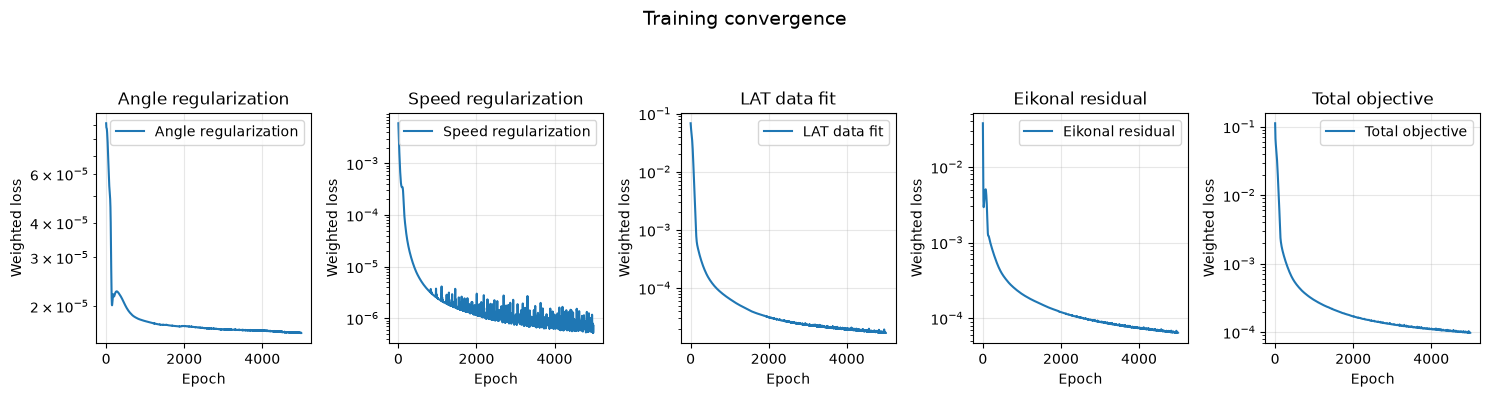

In [18]:
from tqdm.auto import tqdm


n_epochs = 5000
history = []
for _ in tqdm(range(n_epochs)):
    loss, metrics = train_step(lat_model, lat_optimizer, d_model, d_optimizer,
                               mesh_data, observations, loss_weights)
    metrics = {key: float(value) for key, value in jax.device_get(metrics).items()}
    if not all(np.isfinite(value) for value in metrics.values()):
        raise FloatingPointError("Training produced a nonfinite loss.")
    history.append(metrics)

fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(15, 4))
fig.suptitle("Training convergence", fontsize=14)
loss_titles = {"total_loss": "Total objective", "data_loss": "LAT data fit",
               "eikonal_loss": "Eikonal residual", "cv_loss": "Speed regularization",
               "angle_loss": "Angle regularization"}
for i, key in enumerate(history[0].keys()):
    axs[i].semilogy([step[key] for step in history], label=loss_titles.get(key, key))
    axs[i].set_xlabel("Epoch")
    axs[i].set_title(loss_titles.get(key, key))
    axs[i].set_ylabel("Weighted loss")
    axs[i].grid(alpha=0.3)
    axs[i].legend()
plt.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()


### 2.6. Interpret the speed labels

The conduction tensor is unchanged by exchanging the speeds and rotating the
fiber axis by $90^\circ$:

$$
(v_l,v_t,\alpha)\sim(v_t,v_l,\alpha+\pi/2).
$$

Thus regions with opposite speed orderings can represent different choices of
labels. If fibers denote the fastest axis, select the direction associated with
$\max(v_l,v_t)$. Enforcing $v_l\ge v_t$ fixes the labels without fixing their ratio.
When $v_l=v_t$, orientation is unidentifiable; near equality it is weakly constrained.


### 2.7. Recover angles, speeds, and fibers

Convert the inferred fields back to physical quantities:

$$
\alpha=\arccos a,\qquad v_l=\sqrt{e_1},\qquad v_t=\sqrt{e_2}.
$$

A fiber is an axis: $f$ and $-f$ describe identical conduction. For unit reference
and estimated axes, a sign-independent angular error is
$\arccos(|f_{\mathrm{ref}}^T f_{\mathrm{est}}|)$. Compare the fastest axes consistently
and inspect activation-time errors alongside orientation errors.

Restore activation times to physical units and recover the inferred angles, conduction speeds, and tangent directions.


In [19]:
time_scales = np.asarray([obs.time_scale for obs in observations])
predicted_lats = np.asarray(lat_model(mesh_data.features)) * time_scales[:, None]
predicted_parameters = d_model(mesh_data.features)
element_parameters = jnp.mean(predicted_parameters[mesh_data.elements], axis=1)
predicted_D, predicted_fibers, predicted_transverse = build_conduction_tensor(
    element_parameters, mesh_data.long_vec, mesh_data.circ_vec)
a, e1, e2 = np.asarray(element_parameters).T
predicted_angles = np.degrees(np.arccos(np.clip(a, -1.0, 1.0)))
predicted_vl, predicted_vt = np.sqrt(e1), np.sqrt(e2)

Compare inferred and reference fiber axes, and inspect the spatial variation of the two conduction speeds.


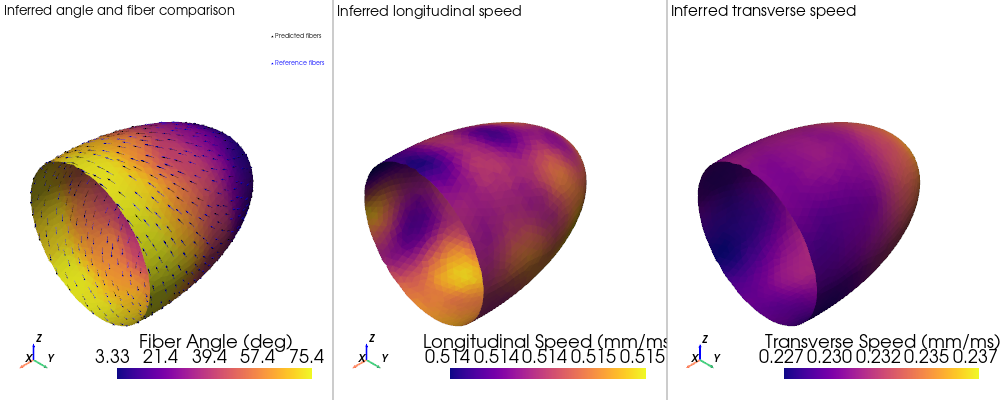

In [20]:
pv.set_jupyter_backend("static")

pl = pv.Plotter(shape=(1, 3), window_size=(1000, 400))
pl.subplot(0, 0)
pl.add_text("Inferred angle and fiber comparison", font_size=10)
pl.add_axes()
pl.add_mesh(poly_coarse, scalars=predicted_angles, cmap="plasma", opacity=1.,
            show_edges=False, scalar_bar_args={"title": "Fiber Angle (deg)"})
pl.add_arrows(elem_centers[random_point_ids], predicted_fibers[random_point_ids],
              mag=2.0, color="black", opacity=1.0, label="Predicted fibers")
pl.add_arrows(elem_centers[random_point_ids], fibers_coarse[random_point_ids],
              mag=2.0, color="blue", opacity=1.0, label="Reference fibers")

pl.add_legend(loc="upper right", size=(0.2, 0.15))

pl.subplot(0, 1)
pl.add_text("Inferred longitudinal speed", font_size=10)
pl.add_axes()
pl.add_mesh(poly_coarse, scalars=predicted_vl, cmap="plasma", opacity=1.,
            show_edges=False, scalar_bar_args={"title": "Longitudinal Speed (mm/ms)"})
pl.subplot(0, 2)
pl.add_text("Inferred transverse speed", font_size=10)
pl.add_axes()
pl.add_mesh(poly_coarse, scalars=predicted_vt, cmap="plasma", opacity=1.,
            show_edges=False, scalar_bar_args={"title": "Transverse Speed (mm/ms)"})
pl.link_views()
pl.show()

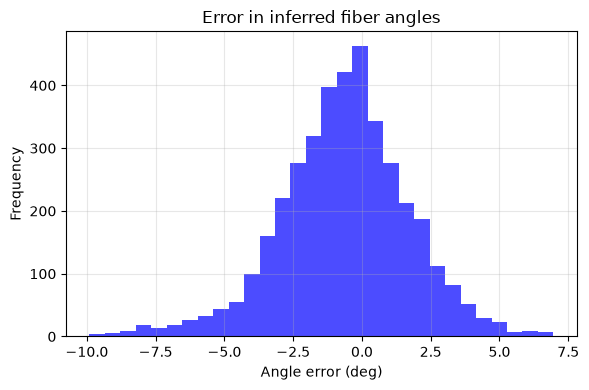

In [21]:
target_angles = sigmoid_func(elem_centers[:, 0], mu=-10, sigma=10) * 90.0
plt.figure(figsize=(6, 4))
plt.hist(predicted_angles - target_angles, bins=30, color="blue", alpha=0.7)
plt.title("Error in inferred fiber angles")
plt.xlabel("Angle error (deg)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Compare reconstructed activation maps with the reference maps; marked locations indicate the observations used for fitting.


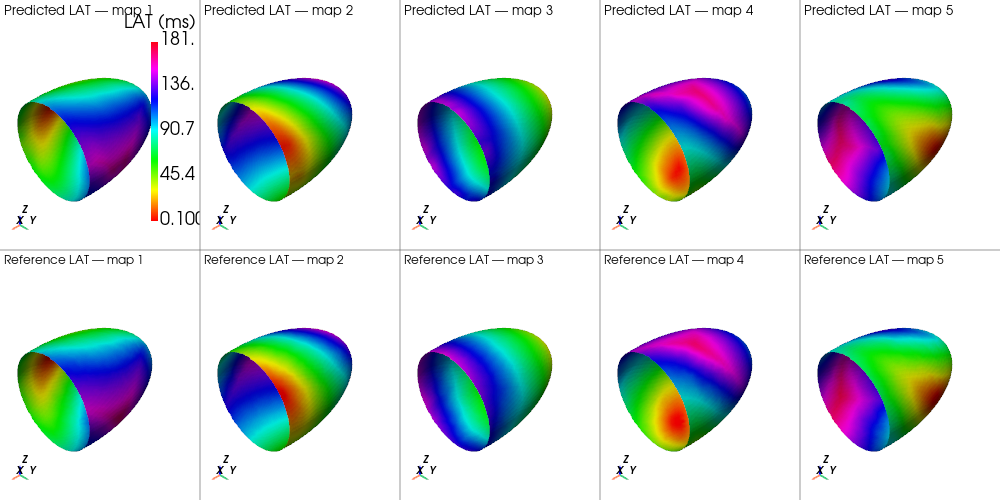

In [22]:
pl = pv.Plotter(shape=(2, len(predicted_lats)), window_size=(1000, 500))
lat_limits = [(float(np.nanmin([pred, ref])), float(np.nanmax([pred, ref])))
              for pred, ref in zip(predicted_lats, lats_coarse)]
for i, lat in enumerate(predicted_lats):
    pl.subplot(0, i)
    pl.add_text(f"Predicted LAT — map {i + 1}", font_size=10)
    pl.add_axes()
    pl.add_mesh(poly_coarse, scalars=lat, cmap="hsv", opacity=1., clim=lat_limits[i],
                show_edges=False,
                scalar_bar_args={"title": "LAT (ms)", "vertical": True,
                                 "position_x": 0.75, "position_y": 0.1,
                                 "width": 0.1, "height": 0.8})

for i, lat in enumerate(lats_coarse):
    pl.subplot(1, i)
    pl.add_text(f"Reference LAT — map {i + 1}", font_size=10)
    pl.add_axes()
    pl.add_mesh(poly_coarse, scalars=lat, cmap="hsv", opacity=1., clim=lat_limits[i],
                show_edges=False,
                scalar_bar_args={"title": "LAT (ms)", "vertical": True,
                                 "position_x": 0.75, "position_y": 0.1,
                                 "width": 0.1, "height": 0.8})
pl.link_views()
pl.show()

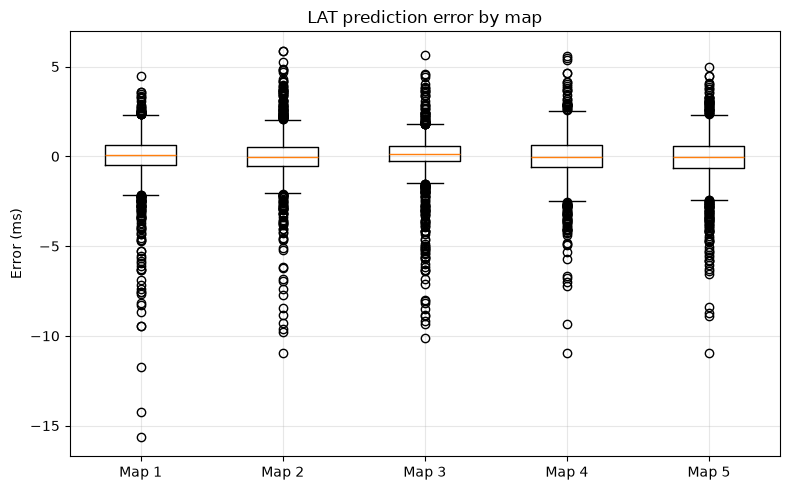

In [23]:
errors = np.asarray(predicted_lats) - np.asarray(lats_coarse)

plt.figure(figsize=(8, 5))
plt.boxplot([errors[i].ravel() for i in range(errors.shape[0])])
plt.title("LAT prediction error by map")
plt.ylabel("Error (ms)")
plt.xticks(ticks=np.arange(1, errors.shape[0] + 1),
           labels=[f"Map {i + 1}" for i in range(errors.shape[0])])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. References

1. Ruiz Herrera, C., et al. (2022). [Physics-informed neural networks to learn cardiac fiber orientation from multiple electroanatomical maps](https://doi.org/10.1007/s00366-022-01709-3). *Engineering with Computers*, 38, 3957–3973. [Author implementation](https://github.com/fsahli/FiberNet).
2. Magaña, Efraín, Simone Pezzuto, and Francisco Sahli Costabal(2025). [Ensemble learning of the atrial fibre orientation with physics‐informed neural networks](https://doi.org/10.1113/JP288001). *The Journal of Physiology*.
3. Raissi, M., Perdikaris, P., and Karniadakis, G. E. (2019). [Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations](https://doi.org/10.1016/j.jcp.2018.10.045). *Journal of Computational Physics*, 378, 686–707.
4. Sahli Costabal, F., Pezzuto, S., and Perdikaris, P. (2024).
[Δ-PINNs: Physics-informed neural networks on complex geometries.](https://arxiv.org/abs/2209.03984)
*Engineering Applications of Artificial Intelligence*, 127, 107324.
